In [14]:
import torch
from torch import nn, optim
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [ ]:
train_transfromer = transforms.Compose([transforms.Resize(32),
                                        transforms.CenterCrop(28),
                                        transforms.RandomHorizontalFlip(),
                                        transforms.ToTensor(),
                                        transforms.Normalize((0.5), (0.5))])

test_transfromer = transforms.Compose([transforms.Resize(32),
                                        transforms.CenterCrop(28),
                                        transforms.RandomHorizontalFlip(),
                                        transforms.ToTensor(),
                                        transforms.Normalize((0.5), (0.5))])


train_data = datasets.CIFAR10("~/.pytorch/CIFAR10/", train=True, download=True, transform=train_transfromer)
test_data = datasets.CIFAR10("~/.pytorch/CIFAR10/", train=False, download=True, transform=test_transfromer)

trainloader = torch.utils.data.DataLoader(train_data, batch_size=62, shuffle=True)
testloader = torch.utils.data.DataLoader(test_data, batch_size=62, shuffle=True)

Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.827451..0.9843137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..0.85882354].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.6627451].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8117647..0.043137312].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].


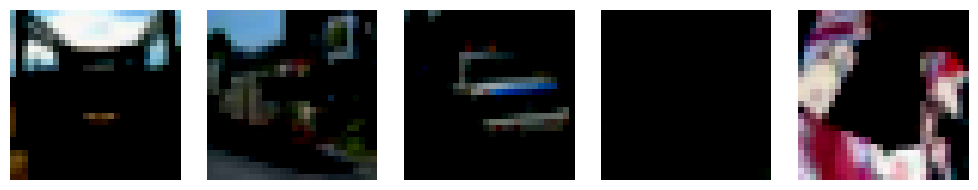

In [16]:
image, label = next(iter(trainloader))
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for n, ax in enumerate(axes):
    flat = image[n].view(-1)
    img = flat.view(3, 28, 28).permute(1, 2, 0)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()

        self.cl1 = nn.Conv2d(3, 16, 3, padding=1)
        self.cl2 = nn.Conv2d(16, 32, 3, padding=1)
        self.cl3 = nn.Conv2d(32, 64, 3, padding=1)

        self.maxpool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512,10)

    def forward(self, x):

        x = self.maxpool(F.relu(self.cl1(x)))
        x = self.maxpool(F.relu(self.cl2(x)))
        x = self.maxpool(F.relu(self.cl3(x)))
        
        x = x.view(x.shape[0], -1)

        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model = Network()
model

Network(
  (cl1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (cl2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (cl3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=26, bias=True)
)